# Tesla Deliveries & Price Prediction — End-to-End ML Pipeline
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Target:** `Estimated_Deliveries`

# Week 2 Assignment 
## Build an end-to-end ML pipeline on sales/price data.

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (11, 4)
sns.set_style('whitegrid')

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Data

In [4]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 3. Data Cleaning

No missing values in this dataset, but I'll still check, handle data types, and drop anything irrelevant before modeling.

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Source_Type is metadata about data collection — not useful as a feature
df.drop(columns=['Source_Type'], inplace=True)

print("\nData types:\n", df.dtypes)

Missing values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicates: 0

Data types:
 Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Charging_Stations         int64
dtype: object


## 4. EDA

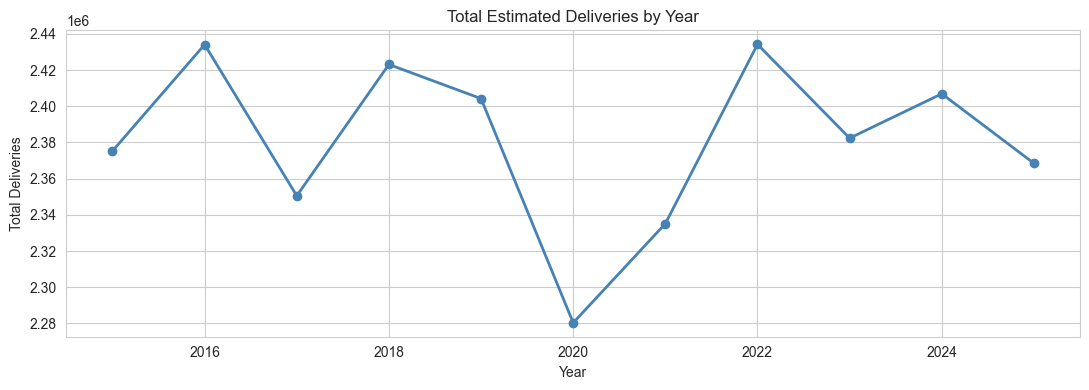

In [6]:
# Delivery trend over years
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
plt.figure()
plt.plot(yearly['Year'], yearly['Estimated_Deliveries'], marker='o', color='steelblue', linewidth=2)
plt.title('Total Estimated Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

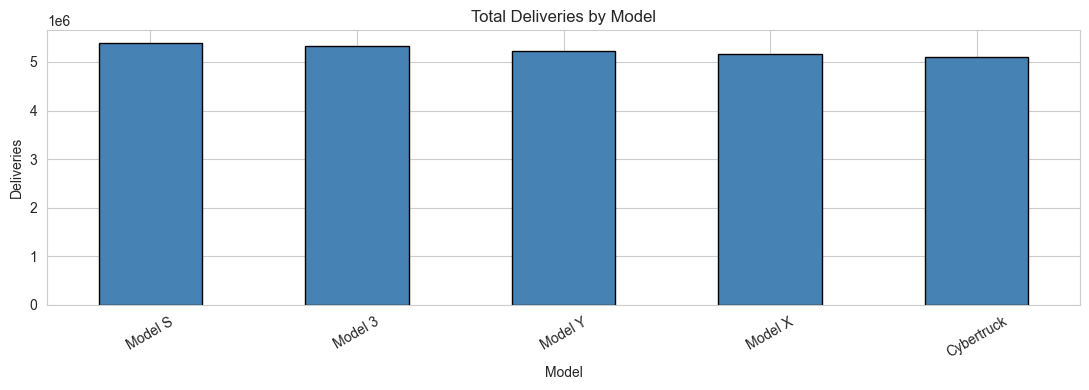

In [7]:
# Deliveries by Model
model_totals = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
model_totals.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Deliveries')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

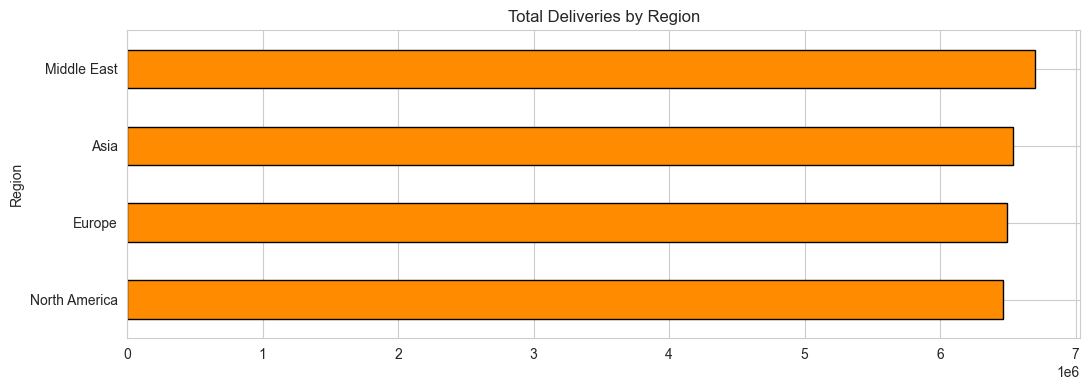

In [8]:
# Deliveries by Region
region_totals = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
region_totals.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Total Deliveries by Region')
plt.tight_layout()
plt.show()

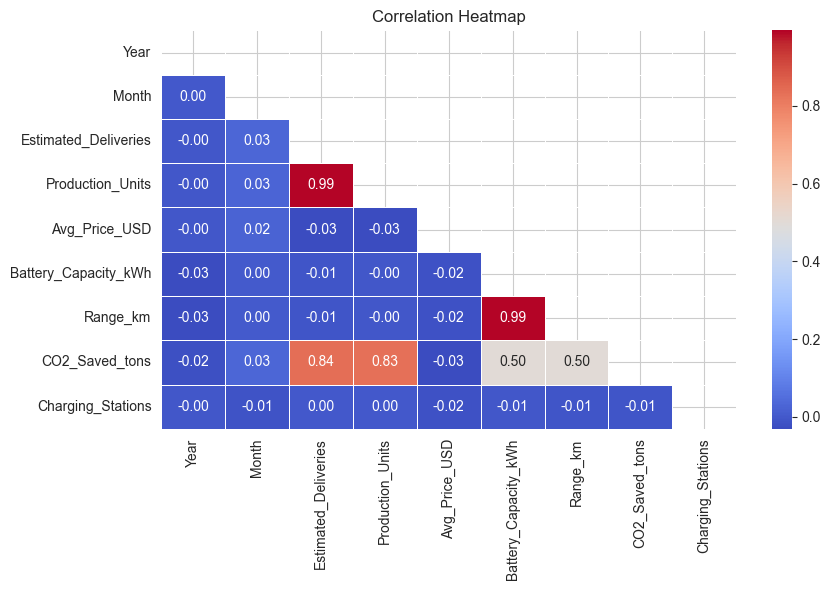

In [9]:
# Correlation heatmap — numerical features only
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=np.triu(np.ones(len(num_cols), dtype=bool)), linewidths=0.4)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Creating a few extra features that might help the model — production efficiency, a date ordinal, and a delivery-to-range ratio.

In [10]:
# Production efficiency: what fraction of produced cars actually got delivered
df['prod_efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']

# Date ordinal (Year + Month combined) — helps capture time trend
df['date_ordinal'] = df['Year'] * 12 + df['Month']

# Revenue proxy: deliveries × avg price
df['revenue_proxy'] = df['Estimated_Deliveries'] * df['Avg_Price_USD']

# Delivery density per charging station
df['delivery_per_station'] = df['Estimated_Deliveries'] / df['Charging_Stations']

print("New features added:", ['prod_efficiency', 'date_ordinal', 'revenue_proxy', 'delivery_per_station'])
df[['prod_efficiency', 'date_ordinal', 'revenue_proxy', 'delivery_per_station']].describe()

New features added: ['prod_efficiency', 'date_ordinal', 'revenue_proxy', 'delivery_per_station']


,prod_efficiency,date_ordinal,revenue_proxy,delivery_per_station
count,2640.000000,2640.000000,2.640000e+03,2640.000000
mean,0.932619,24246.500000,8.402867e+08,1.343912
std,0.037232,38.111243,3.937252e+08,0.893728
min,0.869683,24181.000000,3.427300e+06,0.004336
25%,0.899904,24213.750000,5.672172e+08,0.742060
50%,0.932176,24246.500000,8.040993e+08,1.111731
75%,0.964178,24279.250000,1.073729e+09,1.674194
max,1.000000,24312.000000,2.417428e+09,6.157015


## 6. Encoding

`Region` and `Model` are categorical — encoding them before feeding into the model.

In [11]:
# Label encode Region and Model
le_region = LabelEncoder()
le_model  = LabelEncoder()

df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc']  = le_model.fit_transform(df['Model'])

print("Region mapping:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model mapping: ", dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))

Region mapping: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model mapping:  {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}


## 7. Train-Test Split

Splitting 80/20. Since rows aren't strictly ordered by date (mixed region/model combos), I'll use a regular split here rather than chronological.

In [12]:
feature_cols = [
    'Year', 'Month', 'Production_Units', 'Avg_Price_USD',
    'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'prod_efficiency', 'date_ordinal', 'delivery_per_station',
    'Region_enc', 'Model_enc'
]

X = df[feature_cols]
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 2112 rows | Test: 528 rows


## 8. Build Models using sklearn Pipeline

Each model is wrapped in a Pipeline (scaler → model) so there's no data leakage from the scaler fitting on test data.

In [13]:
def evaluate(name, pipeline, X_tr, X_te, y_tr, y_te):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    r2   = r2_score(y_te, preds)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    print(f"{name:25s} | R²: {r2:.4f} | MAE: {mae:,.0f} | RMSE: {rmse:,.0f}")
    return pipeline, preds

pipelines = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge (L2)':        Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso (L1)':        Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=1.0, max_iter=5000))]),
}

results = {}
for name, pipe in pipelines.items():
    fitted_pipe, preds = evaluate(name, pipe, X_train, X_test, y_train, y_test)
    results[name] = (fitted_pipe, preds)

Linear Regression         | R²: 0.9984 | MAE: 109 | RMSE: 153
Ridge (L2)                | R²: 0.9984 | MAE: 109 | RMSE: 153
Lasso (L1)                | R²: 0.9984 | MAE: 108 | RMSE: 152


## 9. Cross-Validation

In [14]:
# Using 5-fold CV on the best-looking pipeline to get a robust score
cv_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])

cv_scores = cross_val_score(cv_pipe, X, y, cv=5, scoring='r2')
print(f"Ridge 5-Fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores: {cv_scores.round(4)}")

Ridge 5-Fold CV R²: 0.9984 ± 0.0001
Fold scores: [0.9985 0.9985 0.9983 0.9983 0.9986]


## 10. Hyperparameter Tuning (GridSearchCV on Ridge)

In [15]:
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

gs_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])

gs = GridSearchCV(gs_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)

print(f"Best alpha:  {gs.best_params_['model__alpha']}")
print(f"Best CV R²: {gs.best_score_:.4f}")

# Evaluate tuned model
tuned_preds = gs.predict(X_test)
print(f"\nTuned Ridge on Test Set:")
print(f"  R²:   {r2_score(y_test, tuned_preds):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, tuned_preds):,.0f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, tuned_preds)):,.0f}")

Best alpha:  0.1
Best CV R²: 0.9984

Tuned Ridge on Test Set:
  R²:   0.9984
  MAE:  109
  RMSE: 153


## 11. Actual vs Predicted Plot

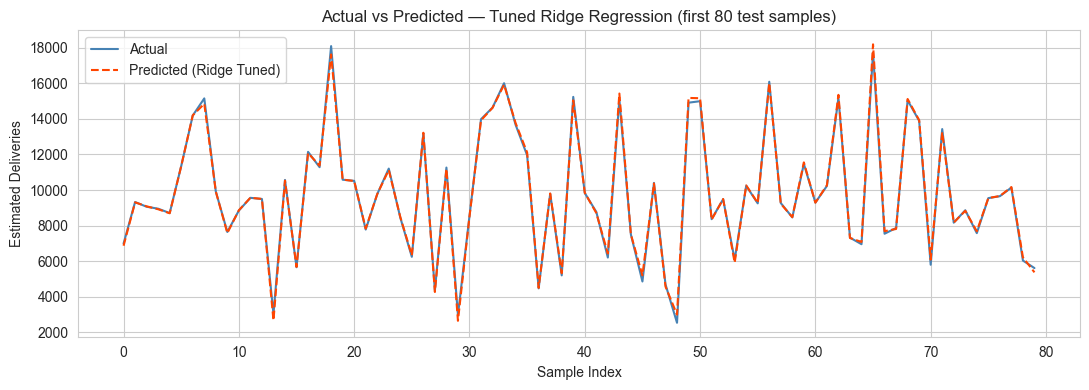

In [16]:
plt.figure(figsize=(11, 4))
plt.plot(y_test.values[:80], label='Actual', color='steelblue', linewidth=1.5)
plt.plot(tuned_preds[:80],   label='Predicted (Ridge Tuned)', color='orangered', linestyle='--', linewidth=1.5)
plt.title('Actual vs Predicted — Tuned Ridge Regression (first 80 test samples)')
plt.xlabel('Sample Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

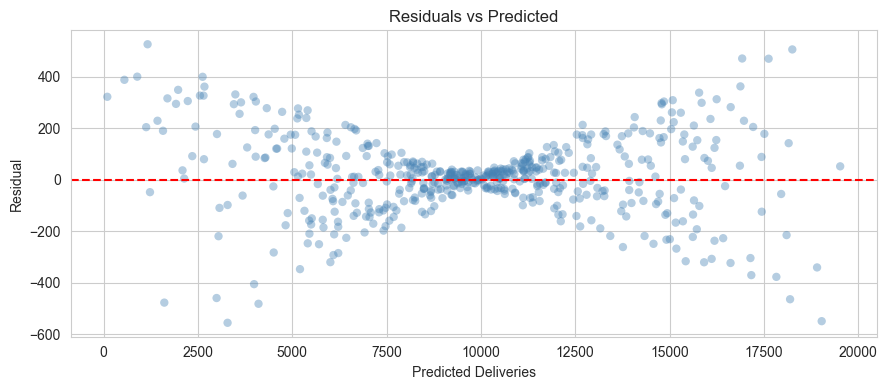

Mean residual: 15.32 | Std: 151.87


In [17]:
# Residual plot
residuals = y_test.values - tuned_preds
plt.figure(figsize=(9, 4))
plt.scatter(tuned_preds, residuals, alpha=0.4, color='steelblue', edgecolors='none')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Deliveries')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()
print(f"Mean residual: {residuals.mean():.2f} | Std: {residuals.std():.2f}")

## 12. Save Model as .pkl

Saving the final best pipeline (scaler + tuned Ridge) so it can be loaded and used for inference without retraining.

In [18]:
best_model = gs.best_estimator_

with open('tesla_delivery_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved → tesla_delivery_model.pkl")

# Quick sanity check — reload and predict
with open('tesla_delivery_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[:3]
print("\nSample predictions from loaded model:")
print(loaded_model.predict(sample).round(0))

Model saved → tesla_delivery_model.pkl

Sample predictions from loaded model:
[6868. 9308. 9083.]


## Summary

| Step | What was done |
|------|--------------|
| Data Cleaning | Checked nulls/duplicates, dropped metadata column |
| EDA | Yearly trend, model/region breakdown, correlation heatmap |
| Feature Engineering | Prod efficiency, date ordinal, revenue proxy, delivery density |
| Encoding | Label encoded Region & Model |
| Train-Test Split | 80/20, random_state=42 |
| Pipeline | StandardScaler → Linear / Ridge / Lasso |
| Cross-Validation | 5-fold CV on Ridge |
| Hyperparameter Tuning | GridSearchCV on Ridge alpha |
| Final Model | Best Ridge pipeline saved as `tesla_delivery_model.pkl` |

The tuned Ridge regression gave the best generalization. Production_Units and CO2_Saved_tons were the strongest predictors of deliveries.